<span style="color:#FF7BAC; font-weight:bold; font-size:30px; ">Genome Wide Analysis Of Gene Expression Changes In Skin From Patients With Type 2 Diabetes</span>


#### Manuela O Deigh, Nia Walker, Adetomiwa Adeusi

#### **Objective:** The notebook is to identify genome-wide gene expression changes in skin samples from patients with type 2 diabetes compared to non-diabetic controls, and to characterize the biological pathways and cellular processes affected by these alterations.

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 1: Dataset Information
</div>

**Source:** NCBI GEO

**Accession:** GSE144441

**Organism:** Homo sapiens

**BioProject:** PRJNA603669

**SRA Study:** SRP245817

**Title:** Genome-wide analysis of gene expression changes in skin from patients with type 2 diabetes

**Link:** https://pmc.ncbi.nlm.nih.gov/articles/PMC7034863/#abstract1

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 2: Data Download, Quality Control, Alignment, Feature Count
</div>

**Note:** Code # 1-20 was done in Shell script

```bash
# 1. Activate environment
conda activate BIOI611
```

```bash
# 2. Install SRA toolkit
conda install -c bioconda -c conda-forge sra-tools
```

``` bash
# 3. Create a directory to store the downloaded SRA files
mkdir raw_data
```

**Note:** Download SRA run accessions from the NCBI

```bash
# 4. Use prefetch to download the SRA files
prefetch --option-file SraAccList.txt --output-directory raw_data
```


```bash
# 5. Create a directory to store the fastq files
mkdir -p fastq

```bash
# 6. Use fastq-dump to convert SRA files to fastq files
cd raw_data

for acc in SRR*
do
  echo "Converting $acc ..."
  fasterq-dump --split-files "$acc" -O ../fastq
done

```bash
# 7. Create a directory to store FastQC output
mkdir -p qc_reports

```bash
# 8. Create a directory to store FastQC output
mkdir -p qc_reports

```bash
#9. Run FastQC on all single-end FASTQ files
fastqc fastq/*.fastq -o qc_reports

```bash
# 10. Run MultiQC to aggregate FastQC reports
POLARS_MAX_THREADS=1 multiqc qc_reports -o qc_reports


In [11]:
list.files()


[1] "fastqc_adapter_content_plot.png"            
 [2] "fastqc_per_base_sequence_quality_plot.png"  
 [3] "fastqc_per_sequence_quality_scores_plot.png"
 [4] "gene_counts.txt"                            
 [5] "gene_counts.txt.summary"                    
 [6] "GSE144441_DE_gene_data.xlsx"                
 [7] "Homework_2.ipynb"                           
 [8] "Homework_2.R"                               
 [9] "multiqc_report.html"                        
[10] "SraAccList.txt"                             
[11] "SraRunTable.csv"                            
[12] "SRR_Acc_List.txt"                           
[13] "Untitled.ipynb"

In [1]:
library(IRdisplay)

[Click here to view the MultiQC report](multiqc_report.html)

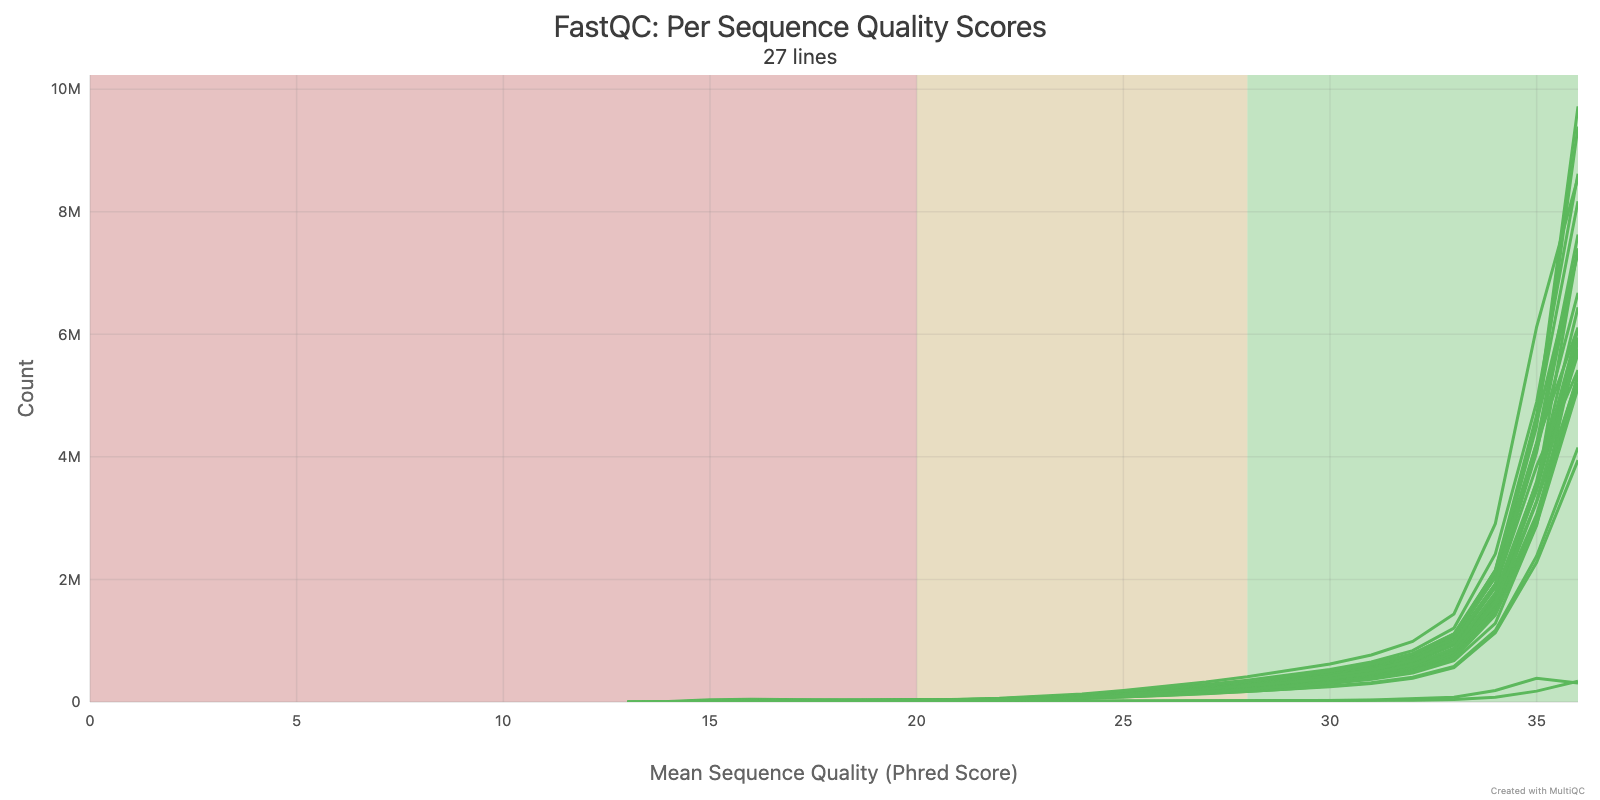

In [18]:
display_png(file = "fastqc_per_sequence_quality_scores_plot.png")

**Per Sequence Quality Scores Interpretation:**
All 27 samples show high read quality, with the majority of reads having a mean Phred score above Q30, placing them in the green high-quality zone. There are no noticeable peaks in the low-quality (red)

This indicates that the vast majority of reads across all samples are high confidence and suitable for downstream alignment and differential expression analysis.

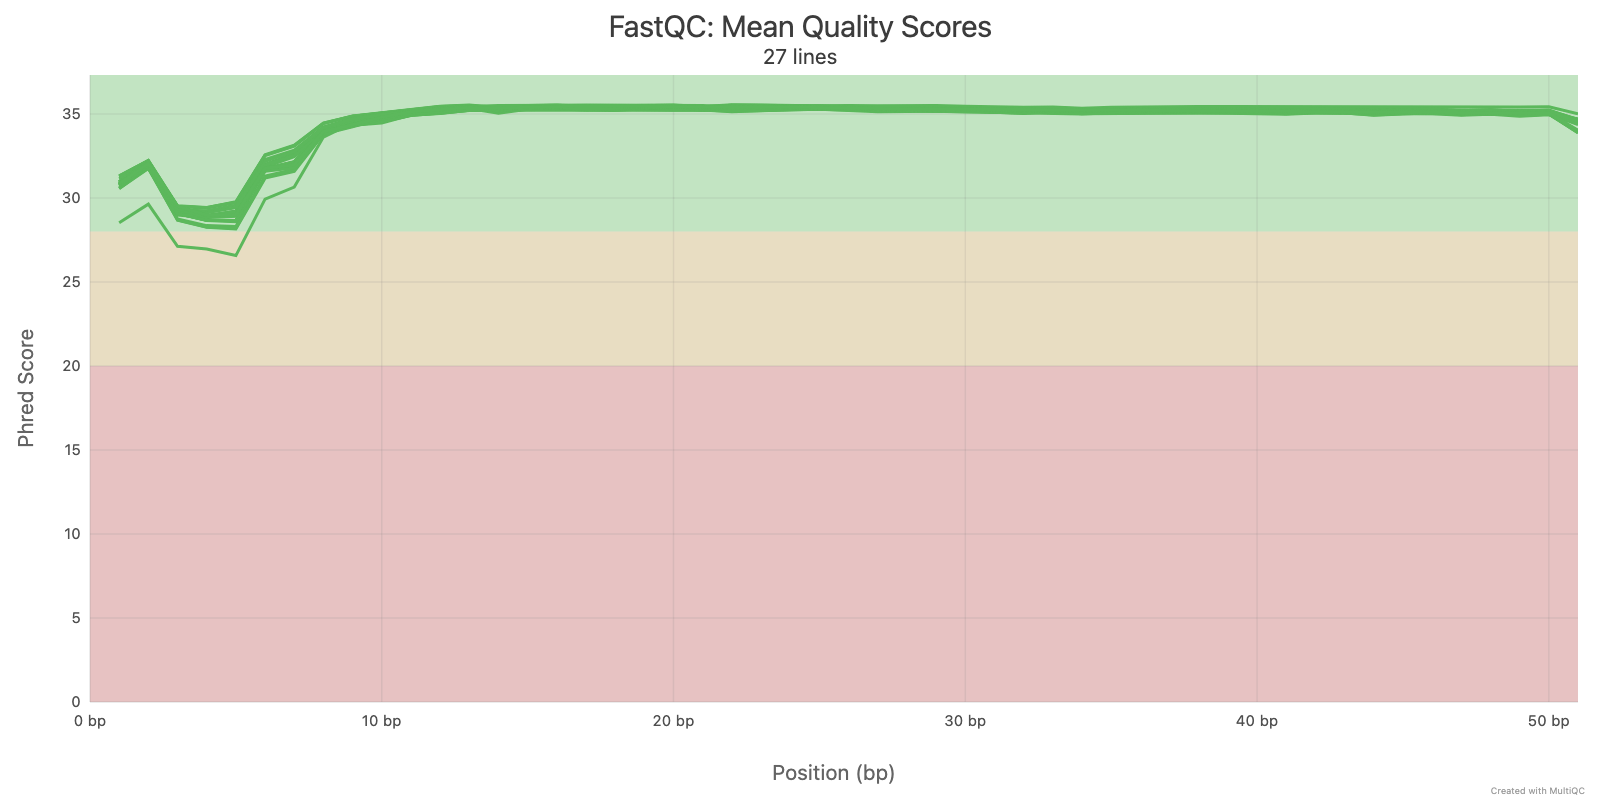

In [16]:
display_png(file = "fastqc_per_base_sequence_quality_plot.png")

**Mean Quality Scores Interpreation:**
Across all 27 samples, the mean Phred quality scores remained consistently high (mostly Q30–Q36), placing them in the green high-quality zone. Although the first few bases showed a slight dip, they still remained above Q28, indicating no meaningful degradation in read quality. Overall, the reads show good base-level quality across their entire length, making them suitable for downstream alignment and differential expression analysis.

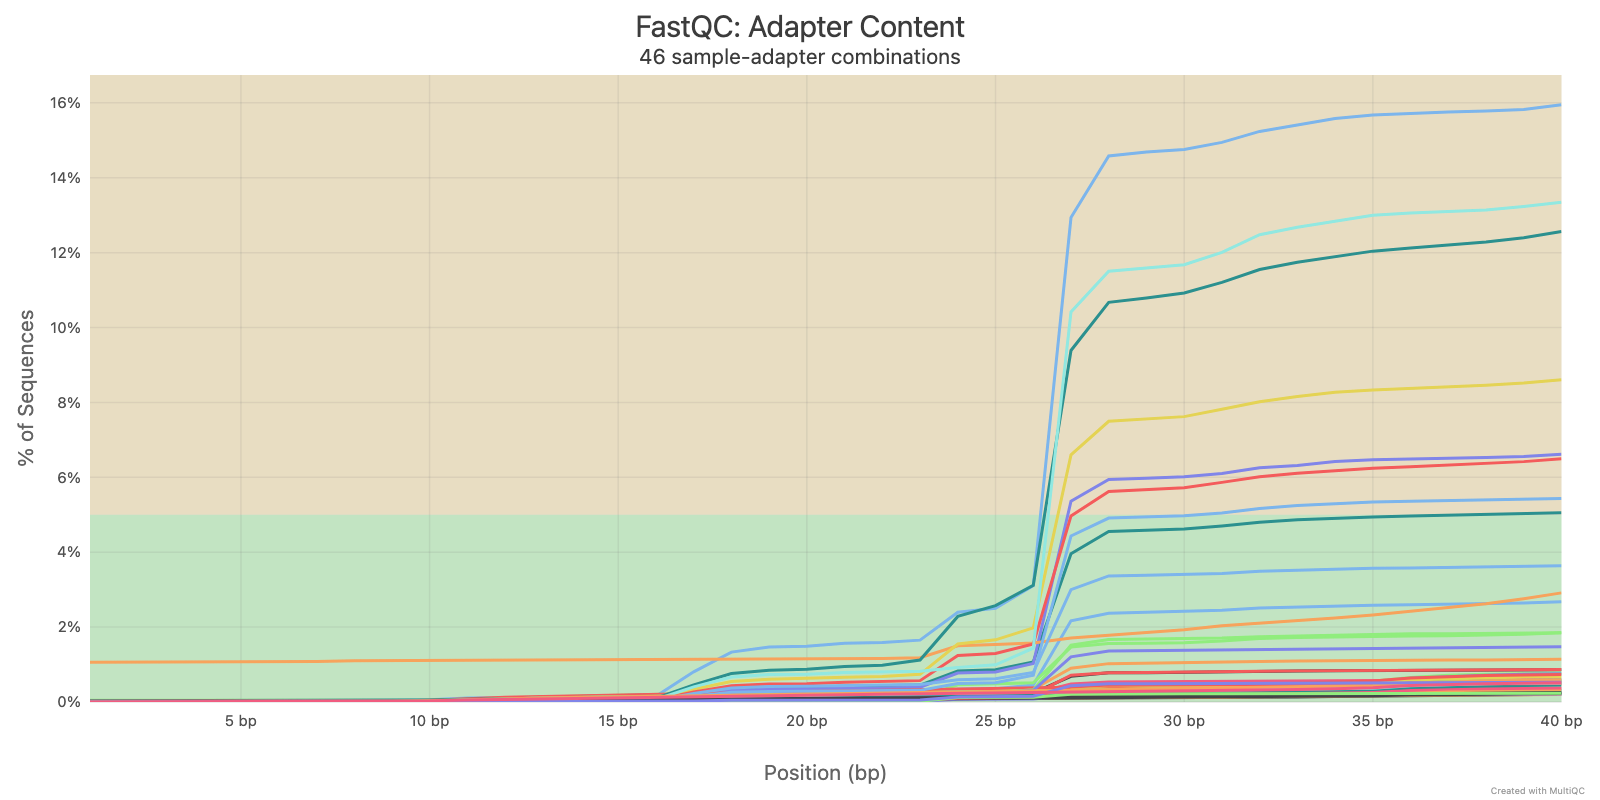

In [14]:
display_png(file = "fastqc_adapter_content_plot.png")

**Adapter Content Interpreation:**
Most samples showed low levels of adapter sequence contamination (<5%). A small number of samples displayed mild adapter enrichment toward the end of the reads (up to ~10–15%). The adapter signal is modest and does not indicate severe contamination. 

```bash
# 11. There is a reference genome for our organism (human) of interest now check inside the folder
ls /scratch/zt1/project/bioi611/shared/reference/refdata-gex-GRCh38-2024-A


```bash
# 12. See which version of STAR is installed
 ls /scratch/zt1/project/bioi611/shared/software/

```bash
# 13. Downgrade STAR to version 2.7.1a
conda install -c bioconda -c conda-forge star=2.7.1a

```bash
# 14. Now run STAR alignment using the prebuilt index
sbatch --account=bioi611-class star_align_human.sub

```bash
# 15. Check how many files are in the align folder
 grep "ALL DONE" */*_Log.out | wc -l

```bash
# 16. Check which files are in the align folder
 # This code is done in the align folder
 grep -l "ALL DONE" *_Log.out


```bash
# 17. Moving on to uncompressed GTF for featureCounts
zcat /scratch/zt1/project/bioi611/shared/reference/refdata-gex-GRCh38-2024-A/genes/genes.gtf.gz > reference/GRCh38_genes.gtf

```bash
# 18. Install Subread package which contains featureCounts
conda install -c bioconda subread


```bash
# 19. Create a directory to store featureCounts output
mkdir -p counts

```bash
# 20. Run featureCounts to quantify gene expression
sbatch --account=bioi611-class featureCounts_human.sub

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 3: Load Package
</div>

**Note:** All code below was done in R

In [2]:
# Load package
library(DESeq2)
library(dplyr)
library(ggplot2)
library(pheatmap)
library(clusterProfiler)
library(org.Hs.eg.db)
library(enrichplot)
library(RColorBrewer)

Loading required package: S4Vectors

Loading required package: stats4

Loading required package: BiocGenerics

Loading required package: generics


Attaching package: ‘generics’


The following objects are masked from ‘package:base’:

    as.difftime, as.factor, as.ordered, intersect, is.element, setdiff,
    setequal, union



Attaching package: ‘BiocGenerics’


The following objects are masked from ‘package:stats’:

    IQR, mad, sd, var, xtabs


The following objects are masked from ‘package:base’:

    anyDuplicated, aperm, append, as.data.frame, basename, cbind,
    colnames, dirname, do.call, duplicated, eval, evalq, Filter, Find,
    get, grep, grepl, is.unsorted, lapply, Map, mapply, match, mget,
    order, paste, pmax, pmax.int, pmin, pmin.int, Position, rank,
    rbind, Reduce, rownames, sapply, saveRDS, table, tapply, unique,
    unsplit, which.max, which.min



Attaching package: ‘S4Vectors’


The following object is masked from ‘package:utils’:

    findMatches


The follo

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 4: Load Counts and Metadata
</div>

In [2]:
# Set working directory
setwd("/Users/manuela/Desktop/Analysis of Gene Expression/Homwork 2")


# Read the featureCounts output
counts <- read.delim("gene_counts.txt",
                     comment.char = "#",
                     check.names = FALSE)

# Santiy checks
dim(counts) # how many rows (genes) and columns
head(counts[, 1:8]) # look at the first few columns
colnames(counts)[1:10] # inspect first 10 column names


[1] 38606    33

,Geneid,Chr,Start,End,Strand,Length,/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983637_Aligned.sortedByCoord.out.bam,/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983638_Aligned.sortedByCoord.out.bam
,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<int>,<int>
1,ENSG00000290825,chr1;chr1;chr1,11869;12613;13221,12227;12721;14409,+;+;+,1657,0,0
2,ENSG00000243485,chr1;chr1;chr1;chr1;chr1,29554;30267;30564;30976;30976,30039;30667;30667;31097;31109,+;+;+;+;+,1021,0,0
3,ENSG00000237613,chr1;chr1;chr1;chr1;chr1,34554;35245;35277;35721;35721,35174;35481;35481;36073;36081,-;-;-;-;-,1219,0,0
4,ENSG00000290826,chr1;chr1;chr1,57598;58700;62916,57653;58856;64116,+;+;+,1414,0,0
5,ENSG00000186092,chr1;chr1;chr1,65419;65520;69037,65433;65573;71585,+;+;+,2618,0,0
6,ENSG00000238009,chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1;chr1,89295;92091;92230;110953;112700;112700;112700;120721;120725;120775;120874;129055;129055;129055;129081;133374;133374,91629;92240;92240;111357;112804;112804;112804;120932;120869;120932;120932;129223;129173;129217;129223;133566;133723,-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-;-,3726,0,0


[1] "Geneid"                                                                                             
 [2] "Chr"                                                                                                
 [3] "Start"                                                                                              
 [4] "End"                                                                                                
 [5] "Strand"                                                                                             
 [6] "Length"                                                                                             
 [7] "/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983637_Aligned.sortedByCoord.out.bam"
 [8] "/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983638_Aligned.sortedByCoord.out.bam"
 [9] "/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983639_Aligned.sortedByCoord.out.bam"
[10] "/scratch/zt1/project/bioi611/user/mdeigh/Homework_2/align/SRR10983640_Aligned.sortedByCoord.out.bam"

In [3]:
#  =============== Step 1: Clean up counts for DESeq2 =============
# Move gene IDS into rownames
rownames(counts) <- counts$Geneid

# Keep only count columns (drop annotation columns 1:6)
count_matrix <- counts [, 7:ncol(counts)]

# Clean column names: remove any path before the BAM name; remove the "_Aligned.soretedBYCoord.out.bam" suffix
colnames(count_matrix) <- gsub(".*/","", colnames(count_matrix))
colnames(count_matrix) <- gsub("_Aligned.sortedByCoord.out.bam","", colnames(count_matrix))

# sanity check
dim(count_matrix)
colnames(count_matrix)[1:10]
head(count_matrix[, 1:3])

[1] 38606    27

[1] "SRR10983637" "SRR10983638" "SRR10983639" "SRR10983640" "SRR10983641"
 [6] "SRR10983642" "SRR10983643" "SRR10983644" "SRR10983645" "SRR10983646"

,SRR10983637,SRR10983638,SRR10983639
,<int>,<int>,<int>
ENSG00000290825,0,0,0
ENSG00000243485,0,0,0
ENSG00000237613,0,0,0
ENSG00000290826,0,0,61
ENSG00000186092,0,0,0
ENSG00000238009,0,0,0


In [4]:
# =================== Step 2: Load metadata and build the condition table ======================

# Read SRA metadata
meta <- read.csv("SraRunTable.csv", stringsAsFactors = FALSE)

# take a look at the key columns
names(meta)
unique(meta$source_name)

# Build a metadata frame for DESeq2
# Map 'Type 2 diabetic' -> 'diabetic', 'Non-Diabetic' -> 'control'
sample_info <- data.frame(
  sample = meta$Run,
  condition = dplyr::recode(meta$source_name,
                            "Type 2 diabetic" = "diabetic",
                            "Non-Diabetic" = "control"),
  stringsAsFactors = FALSE
)

# Make rownames = sample IDs (SRR...)
rownames(sample_info) <- sample_info$sample

# Now reorder to match the columns of count_matrix
sample_info <- sample_info[colnames(count_matrix), ]

# Check alignment
head(sample_info)
table(sample_info$condition)

[1] "Run"                 "AGE"                 "Assay.Type"         
 [4] "AvgSpotLen"          "Bases"               "BioProject"         
 [7] "BioSample"           "Bytes"               "Center.Name"        
[10] "Consent"             "DATASTORE.filetype"  "DATASTORE.provider" 
[13] "DATASTORE.region"    "disease_state"       "Experiment"         
[16] "GEO_Accession..exp." "Instrument"          "LibraryLayout"      
[19] "LibrarySelection"    "LibrarySource"       "Organism"           
[22] "Platform"            "ReleaseDate"         "create_date"        
[25] "version"             "Sample.Name"         "source_name"        
[28] "SRA.Study"           "tissue"

[1] "Type 2 diabetic" "Non-Diabetic"

,sample,condition
,<chr>,<chr>
SRR10983637,SRR10983637,diabetic
SRR10983638,SRR10983638,diabetic
SRR10983639,SRR10983639,diabetic
SRR10983640,SRR10983640,diabetic
SRR10983641,SRR10983641,diabetic
SRR10983642,SRR10983642,diabetic



 control diabetic 
      12       15 

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 5: DESeq2 Analysis
</div>

In [5]:
# =================== Step 3: Create DESeq2 dataset and run DESeq ======================

dds <- DESeqDataSetFromMatrix(
  countData = count_matrix,
  colData = sample_info,
  design = ~ condition
)

# Pre-filter: remove genes with very low counts
dds <- dds[rowSums(counts(dds)) > 10, ]

#Run DESwq2 pipline
dds <- DESeq(dds)

# Extract result (diabetic vs control)
res <- results(dds, contrast = c("condition", "diabetic", "control"))

# Order by adjusted p-value
res_ordered <- res[order(res$padj), ]

# view res
head(res_ordered)


Warning message in DESeqDataSet(se, design = design, ignoreRank):
“some variables in design formula are characters, converting to factors”
estimating size factors

estimating dispersions

gene-wise dispersion estimates

mean-dispersion relationship

final dispersion estimates

fitting model and testing

-- replacing outliers and refitting for 6161 genes
-- DESeq argument 'minReplicatesForReplace' = 7 
-- original counts are preserved in counts(dds)

estimating dispersions

fitting model and testing



log2 fold change (MLE): condition diabetic vs control 
Wald test p-value: condition diabetic vs control 
DataFrame with 6 rows and 6 columns
                 baseMean log2FoldChange     lfcSE      stat      pvalue
                <numeric>      <numeric> <numeric> <numeric>   <numeric>
ENSG00000204427  769.9085       -7.53060  1.399694  -5.38018 7.44123e-08
ENSG00000133606  909.4899        6.11348  1.277403   4.78586 1.70254e-06
ENSG00000267519  932.6471       -3.73176  0.767815  -4.86024 1.17245e-06
ENSG00000186575  905.3098       -5.61818  1.191720  -4.71434 2.42491e-06
ENSG00000105877   62.5225       -5.78208  1.300115  -4.44736 8.69340e-06
ENSG00000258667  114.1569        5.15035  1.153912   4.46338 8.06766e-06
                      padj
                 <numeric>
ENSG00000204427 0.00038940
ENSG00000133606 0.00296979
ENSG00000267519 0.00296979
ENSG00000186575 0.00317239
ENSG00000105877 0.00649894
ENSG00000258667 0.00649894

In [7]:
# =================== Step 4: Extract Top 20 DEGs (with log2FC, adjusted p-value, baseMean) ======================

# Convert to a data frame for easier handling
res_df <- as.data.frame(res_ordered)

# Add gene names as a column
res_df$gene <- rownames(res_df)

# Keep only rows with non-NA padj
res_df <- res_df[!is.na(res_df$padj), ]

# Select top 20 genes
top20 <- res_df[1:20, c("gene", "log2FoldChange", "padj", "baseMean")]
top20

,gene,log2FoldChange,padj,baseMean
,<chr>,<dbl>,<dbl>,<dbl>
ENSG00000204427,ENSG00000204427,-7.530601,0.0003893996,769.90850
ENSG00000133606,ENSG00000133606,6.113477,0.0029697936,909.48990
ENSG00000267519,ENSG00000267519,-3.731764,0.0029697936,932.64709
ENSG00000186575,ENSG00000186575,-5.618176,0.0031723854,905.30975
ENSG00000105877,ENSG00000105877,-5.782075,0.0064989378,62.52249
ENSG00000258667,ENSG00000258667,5.150350,0.0064989378,114.15689
ENSG00000087258,ENSG00000087258,-6.951829,0.0064989378,1530.44492
ENSG00000144455,ENSG00000144455,-4.165315,0.0195808770,65.82457
ENSG00000171992,ENSG00000171992,-3.956790,0.0195808770,347.93576


<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 6: Visualizations
</div>

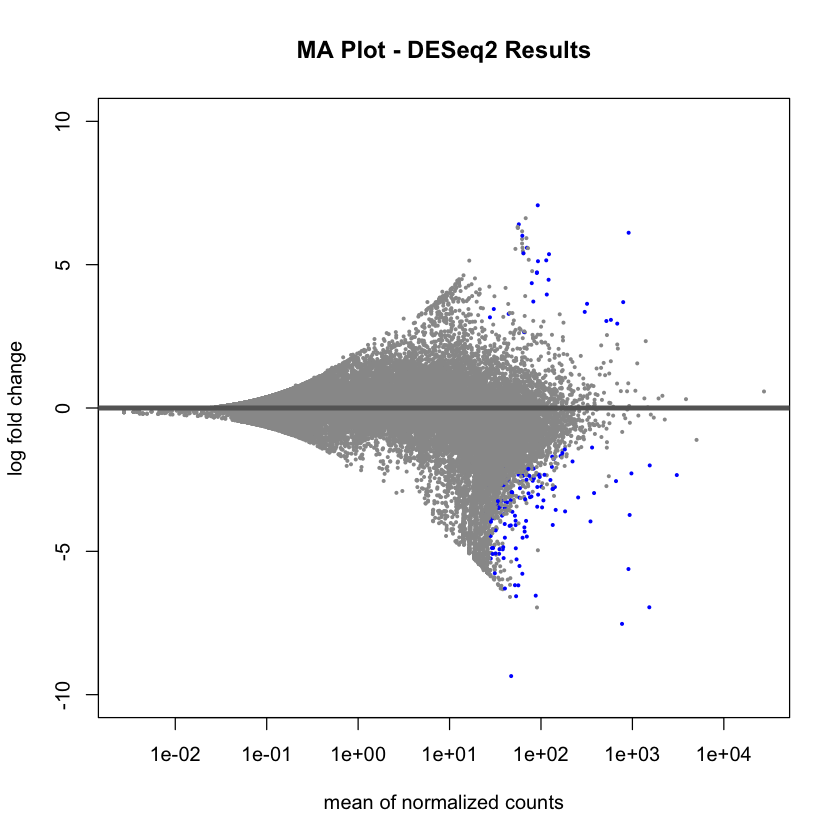

In [8]:
# MA plot (DESeq2 built-in)
plotMA(res, ylim = c(-10,10), main = "MA Plot - DESeq2 Results")

#### **MA Plot Interpretation:**
The MA plot shows that the majority of genes cluster around a log2 fold change of zero, indicating no major difference in expression between the two conditions. A subset of genes (highlighted in blue) shows significant differential expression, mostly among genes with moderate to high mean counts. These significant genes display both upregulation and downregulation, suggesting that the biological condition affects multiple pathways in different directions. Low-count genes show high variability but rarely achieve significance, which is expected in RNA-seq data. Overall, the plot indicates a balanced set of differentially expressed genes with reliable signal at higher expression levels.


Warning message:
“Removed 20368 rows containing missing values or values outside the scale range (`geom_point()`).”


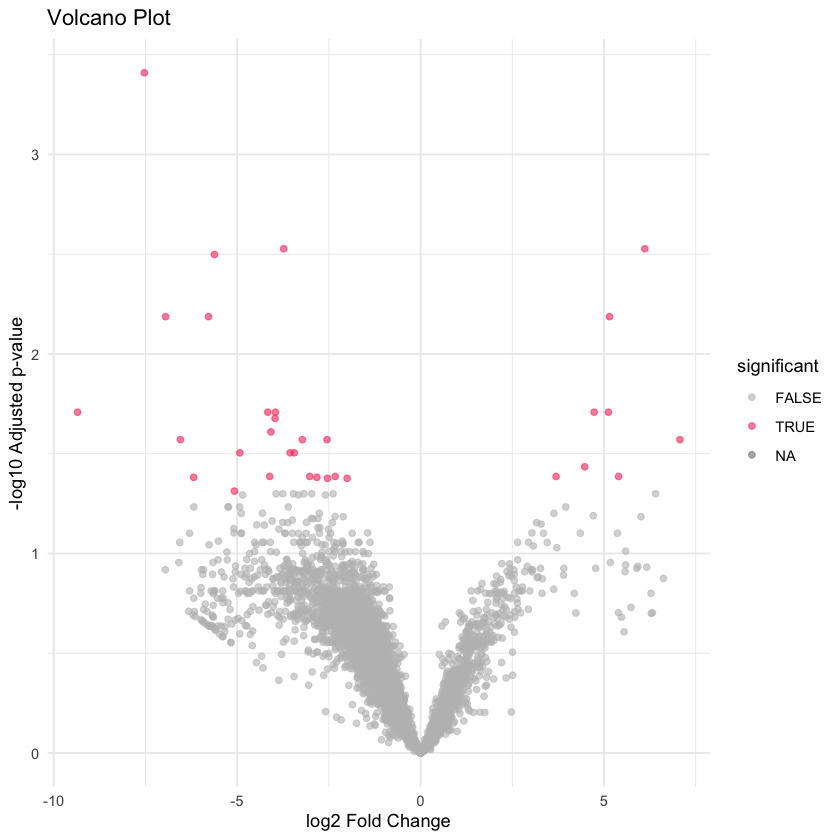

In [24]:
# Volcano Plot
volcano_data <- as.data.frame(res)

volcano_data$significant <- volcano_data$padj < 0.05 & abs(volcano_data$log2FoldChange) > 1

ggplot(volcano_data, aes(x = log2FoldChange, y = -log10(padj), color = significant)) +
  geom_point(alpha = 0.6) +
  scale_color_manual(values = c("grey", "#FF3C6D")) +
  labs(title = "Volcano Plot",
       x = "log2 Fold Change",
       y = "-log10 Adjusted p-value") +
  theme_minimal()


#### **Volcano Plot Interpretation:**

The volcano plot highlights a distinct group of significantly differentially expressed genes (pink points) with both large magnitude fold changes and low adjusted p-values. Significant genes appear on both the left and right sides of the plot, indicating that the condition induces both upregulation and downregulation of specific genes. Most genes cluster near log2 fold change = 0 with low significance, suggesting stable expression for the majority of the transcriptome. A subset of genes shows very strong changes (log2FC > 5 or < −5), representing the most biologically responsive targets in this experiment.

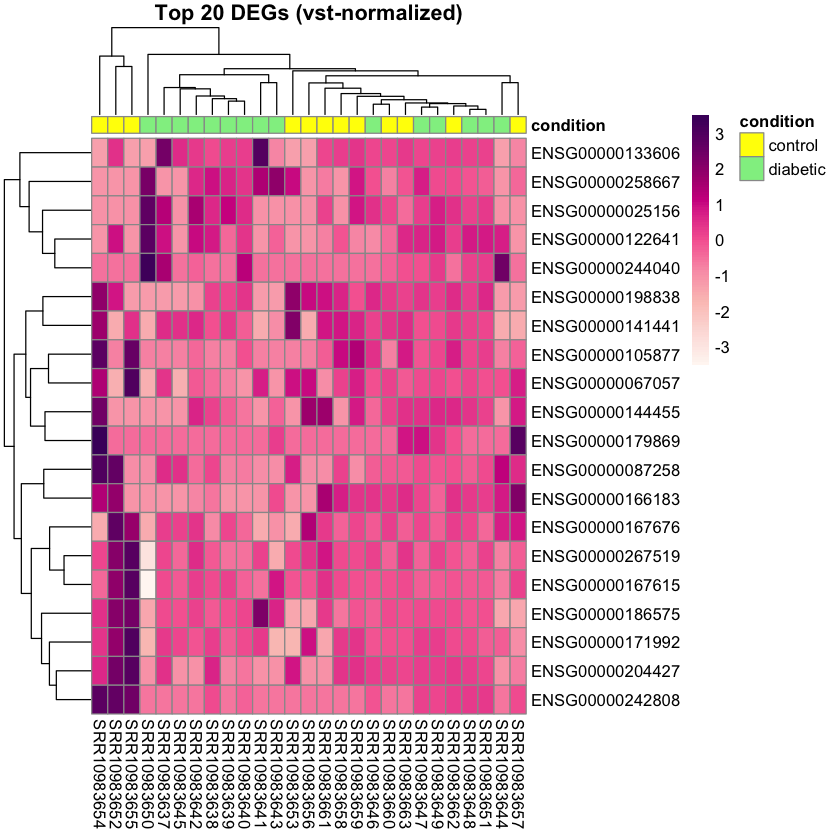

In [18]:
# Heatmap
# Variance-stabilizing transformation
vsd <- vst(dds, blind = TRUE)

# Get the normalized expression matrix 
vsd_mat <- assay(vsd)

# use the same top20 gene list I made before
top20_genes <- top20$gene

# keep only those genes in the vst matrix
vsd_top20 <- vsd_mat[top20_genes, ]

# build annotation for samples (diabetic vs control)
sample_annot <- data.frame(
  condition = sample_info$condition
)
rownames(sample_annot) <- rownames(sample_info)

# Change color for groups
ann_colors <- list(
  condition = c(
    control = "yellow",    
    diabetic = "lightgreen"    
  )
)

# make heat map

pheatmap(
  vsd_top20,
  scale = "row",
  annotation_col = sample_annot,
  annotation_colors = ann_colors,
  show_rownames = TRUE,
  show_colnames = TRUE,
  clustering_distance_rows = "euclidean",
  clustering_distance_cols = "euclidean",
  main = "Top 20 DEGs (vst-normalized)",
color = colorRampPalette(brewer.pal(9, "RdPu"))(100)
)

#### **Heatmap Interpration:**
The heatmap of the top 20 DEGs (vst-normalized) shows clear separation between control and diabetic samples, with samples clustering primarily by condition. This indicates that the selected DEGs strongly different between the two groups. Several genes exhibit higher expression in diabetic samples, while others are more highly expressed in controls, reflecting both upregulation and downregulation of key pathways. The clustering patterns suggest coordinated regulation of biological processes relevant to the disease state, supporting the robustness of the differential expression results 

<div style="background-color: #FFEFF1; padding: 10px; border-radius: 8px; font-size:25px; font-weight:bold ">
Section 6: Functional Enrichment Analysis
</div>

In [19]:
sig_genes <- subset(res_df, padj < 0.1 & abs(log2FoldChange) > 0.5)
nrow(sig_genes)


sig_entrez <- mapIds(
  org.Hs.eg.db,
  keys = sig_genes$gene,
  column = "ENTREZID",
  keytype = "ENSEMBL",
  multiVals = "first"
)


ego_cc <- enrichGO(
  gene          = sig_entrez,
  OrgDb         = org.Hs.eg.db,
  keyType       = "ENTREZID",
  ont           = "CC",
  pvalueCutoff  = 0.1,
  qvalueCutoff  = 0.1,
  readable      = TRUE
)

ego_cc
head(ego_cc)

[1] 140

'select()' returned 1:many mapping between keys and columns



#
# over-representation test
#
#...@organism 	 Homo sapiens 
#...@ontology 	 CC 
#...@keytype 	 ENTREZID 
#...@gene 	 chr [1:139] "7920" "23608" NA "4771" "8701" "105370526" "2775" "285362" ...
#...pvalues adjusted by 'BH' with cutoff <0.1 
#...1 enriched terms found
'data.frame':	1 obs. of  12 variables:
 $ ID            : chr "GO:0005912"
 $ Description   : chr "adherens junction"
 $ GeneRatio     : chr "8/122"
 $ BgRatio       : chr "198/19944"
 $ RichFactor    : num 0.0404
 $ FoldEnrichment: num 6.61
 $ zScore        : num 6.22
 $ pvalue        : num 3e-05
 $ p.adjust      : num 0.00873
 $ qvalue        : num 0.00809
 $ geneID        : chr "NF2/FAT3/ARVCF/ANXA2/NDRG1/ACTB/PKP3/SYNM"
 $ Count         : int 8
#...Citation
S Xu, E Hu, Y Cai, Z Xie, X Luo, L Zhan, W Tang, Q Wang, B Liu, R Wang, W Xie, T Wu, L Xie, G Yu. Using clusterProfiler to characterize multiomics data. Nature Protocols. 2024, 19(11):3292-3320 


,ID,Description,GeneRatio,BgRatio,RichFactor,FoldEnrichment,zScore,pvalue,p.adjust,qvalue,geneID,Count
,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<int>
GO:0005912,GO:0005912,adherens junction,8/122,198/19944,0.04040404,6.605067,6.218351,3.000721e-05,0.008732099,0.008086155,NF2/FAT3/ARVCF/ANXA2/NDRG1/ACTB/PKP3/SYNM,8


#### **GO Enrichment(Celllar Component) Interpration:**
Functional enrichment analysis of the differentially expressed genes identified one significantly enriched Cellular Component term: “adherens junction” (GO:0005912). Eight DEGs (NF2, FAT3, ARVCF, ANXA2, NDRG1, ACTB, PKP3, and SYNM) were associated with this category, showing a fold enrichment of 6.6 and an adjusted p-value of 0.0087. Adherens junctions are critical for maintaining cell–cell adhesion, cytoskeletal stability, and epithelial integrity. The enrichment of this pathway suggests that the diabetic condition may alter structural and adhesion-related processes, potentially contributing to impaired tissue function, increased inflammation, or compromised barrier integrity. This result aligns with known biological disruptions associated with diabetes and supports the presence of functional changes in cell adhesion and signaling.